# How do you do PCA?

*  Step 1: Standardize the range of contionous initial variables
*  Step2: Compute the covariance matrix to identify correlation
*  Step 3: Compute eigen values and eigen vectors of the covarince matrix to identify the principl componenets
*  Step 4: Sort the eigen valies in the descending order to pick the highest one
*  Step 5: Recast the data along the PCA

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
from sklearn.datasets import load_digits

In [13]:
dataset = load_digits()

In [14]:
dataset

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [15]:
dataset.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [17]:
df = pd.DataFrame(dataset.data, columns= dataset.feature_names)

In [18]:
df

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,pixel_1_2,pixel_1_3,pixel_1_4,pixel_1_5,pixel_1_6,pixel_1_7,pixel_2_0,pixel_2_1,pixel_2_2,pixel_2_3,pixel_2_4,pixel_2_5,pixel_2_6,pixel_2_7,pixel_3_0,pixel_3_1,pixel_3_2,pixel_3_3,pixel_3_4,pixel_3_5,pixel_3_6,pixel_3_7,pixel_4_0,pixel_4_1,pixel_4_2,pixel_4_3,pixel_4_4,pixel_4_5,pixel_4_6,pixel_4_7,pixel_5_0,pixel_5_1,pixel_5_2,pixel_5_3,pixel_5_4,pixel_5_5,pixel_5_6,pixel_5_7,pixel_6_0,pixel_6_1,pixel_6_2,pixel_6_3,pixel_6_4,pixel_6_5,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,13.0,15.0,10.0,15.0,5.0,0.0,0.0,3.0,15.0,2.0,0.0,11.0,8.0,0.0,0.0,4.0,12.0,0.0,0.0,8.0,8.0,0.0,0.0,5.0,8.0,0.0,0.0,9.0,8.0,0.0,0.0,4.0,11.0,0.0,1.0,12.0,7.0,0.0,0.0,2.0,14.0,5.0,10.0,12.0,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,9.0,0.0,0.0,0.0,0.0,3.0,15.0,16.0,6.0,0.0,0.0,0.0,7.0,15.0,16.0,16.0,2.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,3.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,3.0,16.0,15.0,14.0,0.0,0.0,0.0,0.0,8.0,13.0,8.0,16.0,0.0,0.0,0.0,0.0,1.0,6.0,15.0,11.0,0.0,0.0,0.0,1.0,8.0,13.0,15.0,1.0,0.0,0.0,0.0,9.0,16.0,16.0,5.0,0.0,0.0,0.0,0.0,3.0,13.0,16.0,16.0,11.0,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,13.0,6.0,15.0,4.0,0.0,0.0,0.0,2.0,1.0,13.0,13.0,0.0,0.0,0.0,0.0,0.0,2.0,15.0,11.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,12.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,10.0,8.0,0.0,0.0,0.0,8.0,4.0,5.0,14.0,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,8.0,0.0,0.0,0.0,0.0,0.0,1.0,13.0,6.0,2.0,2.0,0.0,0.0,0.0,7.0,15.0,0.0,9.0,8.0,0.0,0.0,5.0,16.0,10.0,0.0,16.0,6.0,0.0,0.0,4.0,15.0,16.0,13.0,16.0,1.0,0.0,0.0,0.0,0.0,3.0,15.0,10.0,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,16.0,14.0,12.0,16.0,3.0,0.0,0.0,4.0,16.0,6.0,3.0,16.0,4.0,0.0,0.0,0.0,12.0,16.0,16.0,16.0,5.0,0.0,0.0,0.0,0.0,4.0,4.0,16.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,5.0,0.0,0.0,0.0,5.0,7.0,7.0,16.0,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,16.0,15.0,12.0,16.0,1.0,0.0,0.0,3.0,16.0,7.0,0.0,13.0,6.0,0.0,0.0,4.0,16.0,0.0,0.0,10.0,8.0,0.0,0.0,8.0,16.0,0.0,0.0,14.0,6.0,0.0,0.0,5.0,16.0,7.0,9.0,16.0,5.0,0.0,0.0,1.0,15.0,16.0,16.0,16.0,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,13.0,16.0,8.0,2.0,1.0,0.0,0.0,0.0,16.0,15.0,10.0,16.0,5.0,0.0,0.0,0.0,8.0,16.0,16.0,7.0,0.0,0.0,0.0,0.0,9.0,16.0,16.0,4.0,0.0,0.0,0.0,0.0,16.0,14.0,16.0,15.0,0.0,0.0,0.0,0.0,15.0,15.0,15.0,16.0,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,14.0,16.0,16.0,15.0,1.0,0.0,0.0,4.0,16.0,7.0,3.0,16.0,7.0,0.0,0.0,5.0,16.0,10.0,7.0,16.0,4.0,0.0,0.0,0.0,5.0,14.0,14.0,16.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0,2.0,0.0,0.0,0.0,4.0,7.0,7.0,16.0,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


In [19]:
df['target'] = dataset.target

In [20]:
df

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,pixel_1_2,pixel_1_3,pixel_1_4,pixel_1_5,pixel_1_6,pixel_1_7,pixel_2_0,pixel_2_1,pixel_2_2,pixel_2_3,pixel_2_4,pixel_2_5,pixel_2_6,pixel_2_7,pixel_3_0,pixel_3_1,pixel_3_2,pixel_3_3,pixel_3_4,pixel_3_5,pixel_3_6,pixel_3_7,pixel_4_0,pixel_4_1,pixel_4_2,pixel_4_3,pixel_4_4,pixel_4_5,pixel_4_6,pixel_4_7,pixel_5_0,pixel_5_1,pixel_5_2,pixel_5_3,pixel_5_4,pixel_5_5,pixel_5_6,pixel_5_7,pixel_6_0,pixel_6_1,pixel_6_2,pixel_6_3,pixel_6_4,pixel_6_5,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,13.0,15.0,10.0,15.0,5.0,0.0,0.0,3.0,15.0,2.0,0.0,11.0,8.0,0.0,0.0,4.0,12.0,0.0,0.0,8.0,8.0,0.0,0.0,5.0,8.0,0.0,0.0,9.0,8.0,0.0,0.0,4.0,11.0,0.0,1.0,12.0,7.0,0.0,0.0,2.0,14.0,5.0,10.0,12.0,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,9.0,0.0,0.0,0.0,0.0,3.0,15.0,16.0,6.0,0.0,0.0,0.0,7.0,15.0,16.0,16.0,2.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,3.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,3.0,16.0,15.0,14.0,0.0,0.0,0.0,0.0,8.0,13.0,8.0,16.0,0.0,0.0,0.0,0.0,1.0,6.0,15.0,11.0,0.0,0.0,0.0,1.0,8.0,13.0,15.0,1.0,0.0,0.0,0.0,9.0,16.0,16.0,5.0,0.0,0.0,0.0,0.0,3.0,13.0,16.0,16.0,11.0,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,13.0,6.0,15.0,4.0,0.0,0.0,0.0,2.0,1.0,13.0,13.0,0.0,0.0,0.0,0.0,0.0,2.0,15.0,11.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,12.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,10.0,8.0,0.0,0.0,0.0,8.0,4.0,5.0,14.0,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,8.0,0.0,0.0,0.0,0.0,0.0,1.0,13.0,6.0,2.0,2.0,0.0,0.0,0.0,7.0,15.0,0.0,9.0,8.0,0.0,0.0,5.0,16.0,10.0,0.0,16.0,6.0,0.0,0.0,4.0,15.0,16.0,13.0,16.0,1.0,0.0,0.0,0.0,0.0,3.0,15.0,10.0,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,16.0,14.0,12.0,16.0,3.0,0.0,0.0,4.0,16.0,6.0,3.0,16.0,4.0,0.0,0.0,0.0,12.0,16.0,16.0,16.0,5.0,0.0,0.0,0.0,0.0,4.0,4.0,16.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,5.0,0.0,0.0,0.0,5.0,7.0,7.0,16.0,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0,9
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,16.0,15.0,12.0,16.0,1.0,0.0,0.0,3.0,16.0,7.0,0.0,13.0,6.0,0.0,0.0,4.0,16.0,0.0,0.0,10.0,8.0,0.0,0.0,8.0,16.0,0.0,0.0,14.0,6.0,0.0,0.0,5.0,16.0,7.0,9.0,16.0,5.0,0.0,0.0,1.0,15.0,16.0,16.0,16.0,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0,0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,13.0,16.0,8.0,2.0,1.0,0.0,0.0,0.0,16.0,15.0,10.0,16.0,5.0,0.0,0.0,0.0,8.0,16.0,16.0,7.0,0.0,0.0,0.0,0.0,9.0,16.0,16.0,4.0,0.0,0.0,0.0,0.0,16.0,14.0,16.0,15.0,0.0,0.0,0.0,0.0,15.0,15.0,15.0,16.0,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0,8
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,14.0,16.0,16.0,15.0,1.0,0.0,0.0,4.0,16.0,7.0,3.0,16.0,7.0,0.0,0.0,5.0,16.0,10.0,7.0,16.0,4.0,0.0,0.0,0.0,5.0,14.0,14.0,16.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0,2.0,0.0,0.0,0.0,4.0,7.0,7.0,16.0,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9


In [24]:
df.target.unique()

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [25]:
df.target.value_counts()

target
3    183
1    182
5    182
4    181
6    181
9    180
7    179
0    178
2    177
8    174
Name: count, dtype: int64

<Figure size 640x480 with 0 Axes>

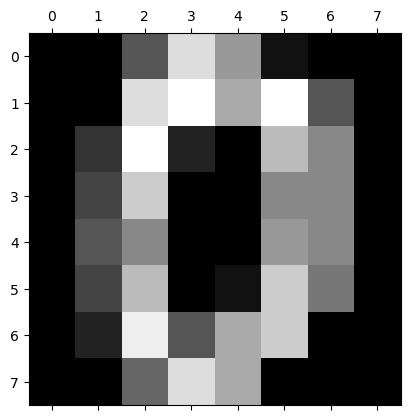

In [28]:
plt.gray()
plt.matshow(dataset.data[0].reshape(8,8))
plt.show()

In [29]:
df.shape

(1797, 65)

In [32]:
#Spliting the data
x = df.iloc[:,:-1]
y = df['target']

In [33]:
x

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,pixel_1_2,pixel_1_3,pixel_1_4,pixel_1_5,pixel_1_6,pixel_1_7,pixel_2_0,pixel_2_1,pixel_2_2,pixel_2_3,pixel_2_4,pixel_2_5,pixel_2_6,pixel_2_7,pixel_3_0,pixel_3_1,pixel_3_2,pixel_3_3,pixel_3_4,pixel_3_5,pixel_3_6,pixel_3_7,pixel_4_0,pixel_4_1,pixel_4_2,pixel_4_3,pixel_4_4,pixel_4_5,pixel_4_6,pixel_4_7,pixel_5_0,pixel_5_1,pixel_5_2,pixel_5_3,pixel_5_4,pixel_5_5,pixel_5_6,pixel_5_7,pixel_6_0,pixel_6_1,pixel_6_2,pixel_6_3,pixel_6_4,pixel_6_5,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,13.0,15.0,10.0,15.0,5.0,0.0,0.0,3.0,15.0,2.0,0.0,11.0,8.0,0.0,0.0,4.0,12.0,0.0,0.0,8.0,8.0,0.0,0.0,5.0,8.0,0.0,0.0,9.0,8.0,0.0,0.0,4.0,11.0,0.0,1.0,12.0,7.0,0.0,0.0,2.0,14.0,5.0,10.0,12.0,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,9.0,0.0,0.0,0.0,0.0,3.0,15.0,16.0,6.0,0.0,0.0,0.0,7.0,15.0,16.0,16.0,2.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,3.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,3.0,16.0,15.0,14.0,0.0,0.0,0.0,0.0,8.0,13.0,8.0,16.0,0.0,0.0,0.0,0.0,1.0,6.0,15.0,11.0,0.0,0.0,0.0,1.0,8.0,13.0,15.0,1.0,0.0,0.0,0.0,9.0,16.0,16.0,5.0,0.0,0.0,0.0,0.0,3.0,13.0,16.0,16.0,11.0,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,13.0,6.0,15.0,4.0,0.0,0.0,0.0,2.0,1.0,13.0,13.0,0.0,0.0,0.0,0.0,0.0,2.0,15.0,11.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,12.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,10.0,8.0,0.0,0.0,0.0,8.0,4.0,5.0,14.0,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,8.0,0.0,0.0,0.0,0.0,0.0,1.0,13.0,6.0,2.0,2.0,0.0,0.0,0.0,7.0,15.0,0.0,9.0,8.0,0.0,0.0,5.0,16.0,10.0,0.0,16.0,6.0,0.0,0.0,4.0,15.0,16.0,13.0,16.0,1.0,0.0,0.0,0.0,0.0,3.0,15.0,10.0,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,16.0,14.0,12.0,16.0,3.0,0.0,0.0,4.0,16.0,6.0,3.0,16.0,4.0,0.0,0.0,0.0,12.0,16.0,16.0,16.0,5.0,0.0,0.0,0.0,0.0,4.0,4.0,16.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,5.0,0.0,0.0,0.0,5.0,7.0,7.0,16.0,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,16.0,15.0,12.0,16.0,1.0,0.0,0.0,3.0,16.0,7.0,0.0,13.0,6.0,0.0,0.0,4.0,16.0,0.0,0.0,10.0,8.0,0.0,0.0,8.0,16.0,0.0,0.0,14.0,6.0,0.0,0.0,5.0,16.0,7.0,9.0,16.0,5.0,0.0,0.0,1.0,15.0,16.0,16.0,16.0,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,13.0,16.0,8.0,2.0,1.0,0.0,0.0,0.0,16.0,15.0,10.0,16.0,5.0,0.0,0.0,0.0,8.0,16.0,16.0,7.0,0.0,0.0,0.0,0.0,9.0,16.0,16.0,4.0,0.0,0.0,0.0,0.0,16.0,14.0,16.0,15.0,0.0,0.0,0.0,0.0,15.0,15.0,15.0,16.0,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,14.0,16.0,16.0,15.0,1.0,0.0,0.0,4.0,16.0,7.0,3.0,16.0,7.0,0.0,0.0,5.0,16.0,10.0,7.0,16.0,4.0,0.0,0.0,0.0,5.0,14.0,14.0,16.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0,2.0,0.0,0.0,0.0,4.0,7.0,7.0,16.0,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


In [34]:
y

0       0
1       1
2       2
3       3
4       4
       ..
1792    9
1793    0
1794    8
1795    9
1796    8
Name: target, Length: 1797, dtype: int32

## PCA

### Step 1 : Stardardise the range of continous initial variables

In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [36]:
x_scaled

array([[ 0.        , -0.33501649, -0.04308102, ..., -1.14664746,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  0.54856067,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  1.56568555,
         1.6951369 , -0.19600752],
       ...,
       [ 0.        , -0.33501649, -0.88456568, ..., -0.12952258,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -0.67419451, ...,  0.8876023 ,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649,  1.00877481, ...,  0.8876023 ,
        -0.26113572, -0.19600752]])

### Step 2 : Covariance matrix

In [38]:
#Transpose of x_scaled matrix for multiplication
x1 = x_scaled.T

In [39]:
pd.DataFrame(x1)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,1757,1758,1759,1760,1761,1762,1763,1764,1765,1766,1767,1768,1769,1770,1771,1772,1773,1774,1775,1776,1777,1778,1779,1780,1781,1782,1783,1784,1785,1786,1787,1788,1789,1790,1791,1792,1793,1794,1795,1796
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,1.870202,-0.335016,5.178030,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,0.767593,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,1.870202,6.280639,-0.335016,2.972811,-0.335016,-0.335016,-0.335016,0.767593,...,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,0.767593,-0.335016,-0.335016,-0.335016,-0.335016,1.870202,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,2.972811,-0.335016,0.767593,-0.335016,-0.335016,0.767593,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016
2,-0.043081,-1.094937,-1.094937,0.377661,-1.094937,1.429517,-1.094937,0.377661,0.798404,1.219146,-0.884566,-1.094937,-0.043081,0.798404,-1.094937,1.429517,-1.094937,-0.884566,1.008775,0.167290,-0.463823,-1.094937,0.588032,0.588032,-1.094937,1.429517,-0.884566,-1.094937,1.008775,0.798404,1.008775,-0.674195,1.639888,1.639888,-1.094937,2.060631,0.167290,1.639888,0.377661,0.798404,...,-0.253452,-0.463823,0.377661,-0.884566,-0.884566,-0.674195,-0.043081,-1.094937,0.377661,0.588032,-1.094937,-0.043081,0.798404,1.008775,-1.094937,-0.043081,-0.674195,0.167290,0.167290,1.429517,-1.094937,-1.094937,-0.463823,1.850259,1.008775,1.008775,2.060631,-0.884566,1.008775,-0.253452,1.008775,-1.094937,0.588032,-0.043081,-1.094937,-0.253452,0.167290,-0.884566,-0.674195,1.008775
3,0.274072,0.038648,-1.844742,0.744919,-2.551014,-0.432200,0.038648,-0.903047,0.509495,0.038648,-0.667624,-2.786437,0.038648,0.744919,-0.903047,0.274072,-0.903047,-0.903047,-1.138471,0.509495,0.274072,-2.315590,0.980343,0.038648,-2.786437,-0.903047,0.274072,-0.903047,-0.196776,0.274072,0.509495,0.274072,0.980343,-1.609319,-1.609319,-0.903047,0.509495,-0.432200,-1.138471,0.980343,...,0.980343,0.274072,0.980343,0.038648,-0.432200,0.274072,0.038648,-2.080166,0.274072,0.038648,-2.315590,0.980343,0.038648,0.038648,-1.373895,0.509495,0.274072,0.038648,0.980343,0.980343,-2.315590,-2.551014,-0.432200,0.744919,0.980343,0.274072,0.274072,-0.432200,0.980343,0.509495,0.980343,-2.551014,0.980343,0.038648,-2.080166,-0.432200,0.980343,-0.196776,-0.432200,0.509495
4,-0.664478,0.268751,0.735366,0.268751,-0.197863,-2.764242,0.268751,0.268751,-0.897785,-2.764242,0.735366,0.502058,-2.530935,0.502058,0.735366,0.968673,0.735366,0.735366,0.268751,-1.831013,-0.197863,0.968673,-1.597706,0.735366,0.035444,-0.897785,0.502058,0.502058,-1.831013,-1.131092,-0.197863,-0.897785,0.968673,-0.897785,0.502058,-0.897785,-0.431170,-2.530935,0.268751,0.268751,...,0.968673,0.968673,-0.664478,-0.431170,0.968673,0.268751,0.268751,0.268751,0.968673,-0.197863,0.968673,-0.431170,0.502058,0.968673,0.035444,-0.197863,-0.431170,0.035444,0.968673,0.968673,0.502058,0.268751,0.968673,-1.364399,0.502058,-2.297628,-2.530935,0.5

In [40]:
cov_mat = np.cov(x1)

In [41]:
pd.DataFrame(cov_mat)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63
0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.0,1.000557,0.556928,0.207929,-0.018771,0.060810,0.048415,-0.038948,0.032338,0.556682,0.224647,-0.109117,0.027923,-0.064019,-0.029990,-0.043722,-0.005112,0.213705,-0.113644,-0.105941,0.096307,-0.170165,-0.131403,-0.038288,-0.011189,-0.085959,-0.146465,0.073021,0.041106,-0.206433,-0.150838,-0.015832,0.0,-0.168389,-0.178587,0.044164,-0.059892,-0.235907,-0.173342,0.0,-0.020563,-0.124336,-0.143079,0.024256,-0.054747,-0.163363,-0.086514,-0.025750,-0.011877,0.225901,0.115345,0.020393,0.031472,-0.009585,0.030970,-0.045368,-0.007910,0.856086,0.556036,0.147728,-0.102406,-0.029887,0.026562,-0.043913
2,0.0,0.556928,1.000557,0.560492,-0.084282,0.043593,0.002842,-0.062313,0.022324,0.582583,0.631819,-0.286185,0.028814,0.063283,-0.089271,-0.100582,-0.016952,0.279019,-0.084298,-0.310899,0.208843,-0.086678,-0.217778,-0.118991,-0.036569,-0.153185,-0.310691,0.108438,0.199873,-0.193867,-0.192188,-0.051745,0.0,-0.344253,-0.396652,-0.055746,-0.120454,-0.279945,-0.183423,0.0,-0.067205,-0.268878,-0.342134,-0.157557,-0.203360,-0.190082,-0.069254,-0.064818,-0.038819,0.205911,0.262322,-0.042555,-0.051559,0.082911,0.050877,-0.003806,-0.025851,0.515563,0.938145,0.500118,-0.134829,-0.041206,0.072639,0.082569
3,0.0,0.207929,0.560492,1.000557,0.023952,-0.171473,-0.115796,-0.040162,0.035683,0.328527,0.596812,-0.002442,-0.068664,0.023176,-0.178903,-0.113894,0.022749,0.187916,0.040538,-0.360640,0.067980,-0.018325,-0.225018,-0.149841,-0.002641,-0.109321,-0.256436,-0.057140,0.090228,-0.183359,-0.141853,-0.067710,0.0,-0.227582,-0.224502,0.017616,-0.078007,-0.226619,-0.037244,0.0,-0.099680,-0.257979,-0.102260,-0.025316,-0.243965,-0.214864,0.089753,0.046945,-0.062833,0.015456,0.299929,0.279576,-0.180632,0.022409,0.139475,0.075376,-0.049112,0.175902,0.560638,0.768373,-0.065993,-0.054966,0.053467,0.082016
4,0.0,-0.018771,-0.084282,0.023952,1.000557,0.508014,0.127835,0.010070,0.042089,0.051686,0.014006,-0.135790,0.160358,0.390252,0.133699,0.014513,0.009916,0.036632,-0.124521,-0.155587,-0.029041,0.182773,0.078376,0.023900,0.008976,0.027058,-0.063230,0.036251,0.089704,0.122616,0.078100,0.012701,0.0,-0.028088,-0.015673,0.026608,0.069954,0.089136,0.051437,0.0,0.023655,-0.018374,-0.095207,-0.037596,0.051742,0.074616,-0.090171,-0.039552,0.024162,-0.020588,-0.165693,-0.043673,0.030331,-0.120628,-0.265116,-0.212339,0.017362,-0.047250,-0.020187,-0.008872,-0.082171,-0.215929,-0.250838,-0.215469
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0.0,0.147728,0.500118,0.768373,-0.008872,-0.068076,-0.045871,0.001013,0.043398,0.305361,0.634445,0.048290,-0.160577,0.070561,-0.066914,-0.055108,0.021551,0.227565,0.140454,-0.340207,-0.063278,-0.015597,-0.130327,-0.110918,-0.000680,-0.023925,-0.189694,-0.053607,0.036487,-0.190487,-0.157863,-0.030678,0.0,-0.212819,-0.285548,-0.077900,-0.116675,-0.195208,-0.041779,0.0,-0.078437,-0.232945,-0.163889,-0.166237,-0.198045,-0.129254,0.081948,0.006893,-0.040630,0.036485,0.229197,0.153751,-0.061718,0.065216,0.094770,0.050060,-0.038269,0.113035,0.481979,1.000557,0.058423,-0.095009,0.006853,0.099727
60,0.0,-

### Step 3 : Eigen value and Eigen vector

In [42]:
eig_value, eig_vector = np.linalg.eig(cov_mat)

In [47]:
#how much an eigenvector gets stretched or compressed during the transformation
pd.DataFrame(eig_value)

,0
0,7.344776
1,5.835491
2,5.153961
3,3.966236
4,2.966345
...,...
59,0.200091
60,0.189835
61,0.000000
62,0.000000


In [48]:
# Eigenvectors are the vectors indicating the direction of the axes along which the data varies the most
pd.DataFrame(eig_vector)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.0,0.0
1,0.182234,-0.047027,0.023588,-0.178153,-0.029978,0.231723,-0.108310,-0.125524,-0.213820,-0.059834,0.049941,0.204254,0.133801,-0.041487,0.130818,0.082027,-0.171821,-0.065722,0.137138,-0.098283,-0.006642,0.029304,0.114117,-0.196266,0.101727,0.120121,-0.037933,0.095185,0.097288,0.046406,0.069916,0.050244,0.060175,-0.002171,-0.102210,0.087139,0.024623,-0.022276,0.063996,-0.026354,0.022867,-0.085241,-0.015791,-0.016542,-0.023658,-0.013188,0.064751,0.562510,-0.134134,-0.203051,0.159522,-0.023657,0.136114,-0.168755,0.039356,-0.036629,0.082404,0.052290,0.197267,0.024853,0.052605,0.0,0.0,0.0
2,0.285868,-0.059565,-0.056799,-0.156129,-0.014666,0.119875,-0.004755,-0.006178,-0.120140,-0.007681,0.147540,-0.044570,0.031574,0.038609,-0.100309,0.022455,0.018188,0.016911,0.020551,0.025342,0.117158,-0.005074,-0.134998,0.011292,0.011514,-0.068861,0.158987,-0.058283,-0.269276,-0.025233,-0.010893,-0.047724,-0.069043,0.008342,0.095020,-0.024501,-0.025384,0.141543,-0.187823,0.686446,-0.139281,-0.033334,0.052102,0.044499,0.101491,0.098357,-0.024959,0.036255,0.067830,-0.076872,0.002794,-0.021571,0.052227,-0.008411,-0.080164,0.176636,0.091203,-0.001822,-0.129372,-0.069592,-0.090823,0.0,0.0,0.0
3,0.220370,0.020804,-0.040464,-0.167800,0.043716,-0.100392,0.233717,0.033408,0.101895,0.021639,0.155505,-0.188568,0.064244,0.183513,-0.044552,0.074244,-0.024539,0.010330,-0.024455,0.001167,0.039253,-0.106731,0.031537,-0.134422,0.114013,0.030726,-0.129626,0.097933,-0.086204,0.171524,-0.024466,0.040695,0.122914,0.030803,0.100501,-0.099773,-0.121309,-0.140677,0.192645,-0.018188,-0.015434,0.099778,0.074707,0.120277,-0.060721,0.067932,0.080744,0.057566,-0.069727,0.227598,0.161706,-0.138867,-0.312667,-0.251349,0.125306,-0.224852,-0.089657,0.040788,-0.148353,0.052446,-0.323498,0.0,0.0,0.0
4,-0.025170,-0.155903,-0.067065,0.000009,-0.139993,-0.093471,-0.039540,-0.046161,0.093102,-0.005066,-0.163472,-0.059178,0.073513,0.158989,0.299957,0.291598,0.043592,-0.329826,-0.215418,0.183349,0.089078,-0.313472,0.256792,-0.136360,-0.042908,-0.127998,-0.010016,-0.076130,-0.050861,0.177831,0.069299,-0.090964,0.089213,0.010605,-0.164332,-0.037811,-0.040325,0.135681,0.004931,0.056287,0.013144,0.208727,0.039015,0.165961,0.035744,-0.045223,-0.070202,-0.000663,0.033402,-0.099464,-0.109118,0.204155,0.139449,0.022663,0.049967,-0.024456,0.039529,0.012110,-0.072823,-0.057241,0.048470,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0.194449,0.009905,-0.083464,-0.171490,0.100375,-0.086503,0.135319,0.098852,0.115978,0.105825,0.121201,-0.236655,0.042706,0.262494,-0.081153,0.074291,-0.013292,0.040549,-0.045488,-0.015010,-0.106982,-0.089599,0.120630,-0.040321,0.237434,0.131049,-0.033045,0.016252,0.057169,0.048019,-0.084464,0.034424,0.038414,0.057748,0.177854,-0.051180,0.050351,-0.165062,-0.006137,0.042972,0.110623,-0.105299,-0.032100,-0.252308,-0.045709,-0.005867,-0.137432,-0.060826,-0.019611,-0.181839,-0.108749,0.135819,0.214148,0.248310,-0.067003,0.101720,-0.245611,-0.069682,0.336075,0.080163,0.138750,0.0,0.0,0.0
60,0.017774,0.251934,-0.062455,

In [49]:
total = sum(eig_value)

In [50]:
total

61.03396436525616

### Step 4 : Sorting

In [51]:
var_exp = [i/total * 100 for i in sorted(eig_value, reverse=True)]

In [52]:
var_exp

[12.033916097734915,
 9.561054403097891,
 8.44441489262456,
 6.49840790752418,
 4.860154875966401,
 4.214119869271918,
 3.9420828035673936,
 3.3893809246383313,
 2.998221011625239,
 2.9320025512522094,
 2.7818054635502962,
 2.5770550925819933,
 2.2753033157642393,
 2.22717973951436,
 2.1652294318492435,
 1.9141666064421339,
 1.7755470851682105,
 1.6380692742844174,
 1.5964601688623552,
 1.4891911870878147,
 1.3479695658179345,
 1.2719313702347725,
 1.165837350591948,
 1.0576465985363235,
 0.9753159471981055,
 0.9445589897320025,
 0.86301382697072,
 0.8366428536685085,
 0.7976932484112421,
 0.7464713709260682,
 0.7255821513702747,
 0.6919112454811825,
 0.6539085355726199,
 0.6407925738459875,
 0.5913841117223426,
 0.5711624052235242,
 0.523636803416631,
 0.4818075864451429,
 0.45371925985844935,
 0.4231627532327793,
 0.40605306997903745,
 0.3970848082758276,
 0.35649330314261796,
 0.3407871814703008,
 0.32783533528795383,
 0.3110320073453573,
 0.2885752941089336,
 0.27648926352354436,
 

### Step 5 : Cumulatative variance
How many principal components do i keep so i don't lose important information

In [53]:
cum_var_exp = np.cumsum(var_exp)

In [54]:
pd.DataFrame(cum_var_exp)

,0
0,12.033916
1,21.594971
2,30.039385
3,36.537793
4,41.397948
...,...
59,99.917465
60,100.000000
61,100.000000
62,100.000000


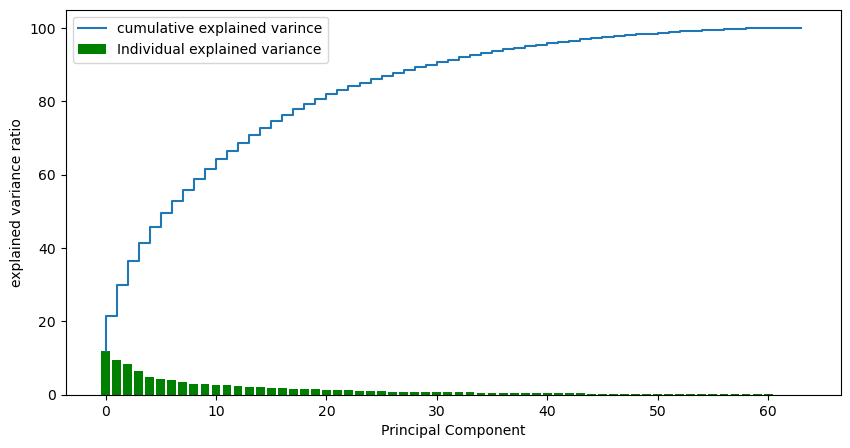

In [57]:
plt.figure(figsize=(10,5))
plt.bar(range(len(var_exp)),var_exp, label='Individual explained variance',color='g')
plt.step(range(len(cum_var_exp)),cum_var_exp,label='cumulative explained varince')
plt.xlabel('Principal Component')
plt.ylabel('explained variance ratio')
plt.legend()
plt.show()

## Apply PCA

In [58]:
from sklearn.decomposition import PCA

In [60]:
# this tells pca to retain enough componenents such tht 95% of the variance in the data should be be presevered
pca = PCA(0.95)

In [66]:
x_pca = pca.fit_transform(x_scaled)


In [67]:
x_pca.shape

(1797, 40)

### Apply LogisticRegression

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [70]:
x_train_pca, x_test_pca, y_train, y_test = train_test_split(x_pca, y, test_size=0.2, random_state=43)

In [71]:
model = LogisticRegression(max_iter=1000)

In [72]:
model.fit(x_train_pca, y_train)

LogisticRegression(max_iter=1000)

In [73]:
y_pred = model.predict(x_test_pca)

In [74]:
y_pred

array([1, 8, 3, 8, 6, 0, 6, 5, 1, 1, 7, 1, 3, 9, 2, 6, 0, 4, 7, 4, 7, 0,
       0, 8, 5, 0, 8, 2, 3, 3, 8, 6, 9, 4, 0, 7, 6, 7, 4, 8, 9, 6, 4, 0,
       4, 6, 4, 4, 6, 0, 5, 0, 5, 4, 5, 9, 7, 5, 7, 4, 4, 6, 4, 6, 5, 4,
       1, 5, 6, 4, 7, 4, 2, 6, 7, 4, 0, 4, 0, 5, 8, 0, 3, 5, 9, 6, 0, 5,
       3, 0, 0, 4, 6, 9, 6, 6, 9, 4, 6, 9, 3, 7, 8, 9, 7, 0, 3, 3, 6, 7,
       5, 2, 1, 1, 7, 7, 7, 7, 7, 0, 9, 2, 5, 7, 7, 4, 8, 3, 2, 6, 8, 0,
       1, 6, 4, 4, 8, 0, 9, 0, 1, 6, 1, 7, 3, 2, 0, 5, 0, 7, 8, 9, 6, 0,
       1, 5, 7, 1, 0, 7, 4, 1, 7, 9, 8, 2, 6, 4, 9, 7, 7, 5, 8, 0, 2, 9,
       5, 6, 4, 5, 4, 2, 9, 6, 4, 1, 8, 7, 8, 7, 2, 6, 1, 6, 1, 4, 2, 6,
       1, 8, 3, 6, 9, 0, 8, 2, 9, 4, 7, 9, 8, 4, 5, 2, 1, 9, 1, 8, 6, 2,
       9, 8, 1, 1, 1, 5, 2, 8, 8, 5, 9, 2, 9, 2, 9, 2, 1, 8, 8, 9, 6, 8,
       3, 1, 0, 3, 1, 1, 5, 4, 7, 6, 2, 4, 6, 4, 9, 9, 2, 0, 6, 5, 6, 0,
       3, 7, 5, 0, 0, 3, 4, 5, 8, 9, 2, 1, 6, 7, 9, 6, 9, 3, 3, 7, 4, 3,
       5, 8, 9, 4, 0, 0, 9, 8, 1, 0, 4, 3, 7, 6, 3,

In [75]:
from sklearn.metrics import accuracy_score

In [77]:
accuracy_score(y_pred, y_test) * 100

97.22222222222221